In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

In [2]:
data = load_breast_cancer()

In [5]:
X = data.data
y = data.target

In [ ]:
X.shape

(569, 30)

In [7]:
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [8]:
pd.Series(y).value_counts()

1    357
0    212
Name: count, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10)

knn.fit(X_train, y_train)

accuracy = knn.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.9736842105263158


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

accuracy = knn.score(X_test_scaled, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.9473684210526315


In [13]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

scores = []

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    scores.append(accuracy_score(y_test, y_pred))

print(max(scores))
print(scores.index(max(scores)) + 1)

0.9649122807017544
9


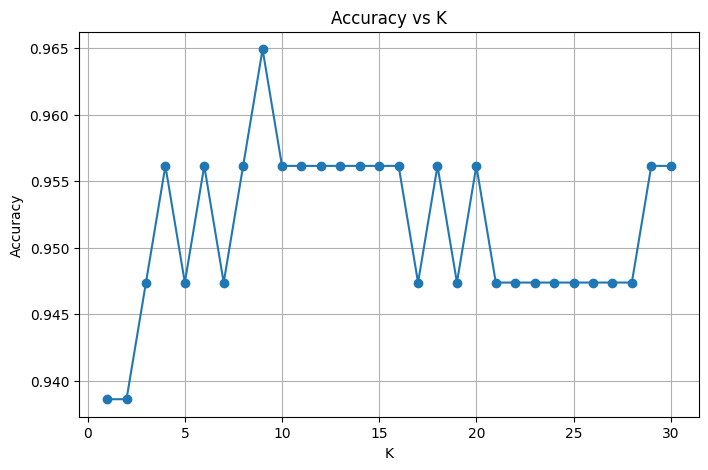

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1,31), scores, marker='o')

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)

plt.show()